## Load libraries and data & preprocessing

In [1]:
# load necessary libraries 
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import numpy as np
import gseapy as gp

In [2]:
# load data 
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 190804 × 23711
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',

In [3]:
# split in conditions 
adata_control = adata[adata.obs['condition'] == 'Control'].copy()
adata_IFN_gamma = adata[adata.obs['condition'] == 'IFNγ'].copy()
adata_co_culture = adata[adata.obs['condition'] == 'Co-culture'].copy()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


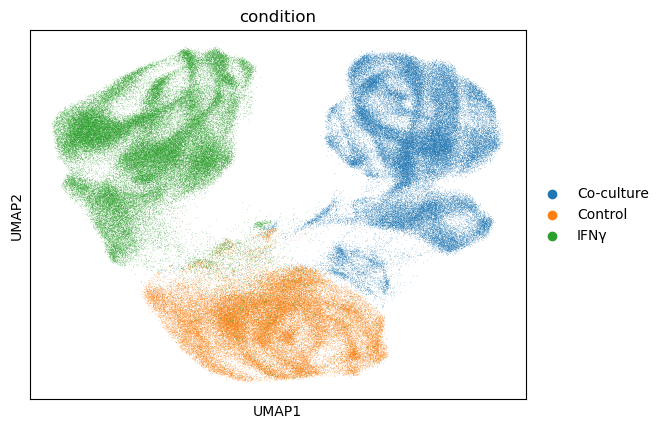

In [4]:
# UMAP over all data
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.umap(adata)
sc.pl.umap(adata, color="condition")

## Pseudo Bulk mean expression profiles per KO

In [5]:
# calculate pseudo-bulk: mean profile per pertubation group
pertubation_bulk_adata = sc.get.aggregate(adata, by=['condition', 'perturbation'], func='mean', layer = "counts")
pertubation_bulk_adata.X = pertubation_bulk_adata.layers['mean'].copy()

df_expr = pertubation_bulk_adata.to_df()
df_obs = pertubation_bulk_adata.obs

In [6]:
print(df_obs)

                   condition perturbation  n_obs_aggregated
Co-culture_A2M    Co-culture          A2M               380
Co-culture_ACSL3  Co-culture        ACSL3               164
Co-culture_ACTA2  Co-culture        ACTA2               392
Co-culture_AEBP1  Co-culture        AEBP1               347
Co-culture_AGA    Co-culture          AGA               340
...                      ...          ...               ...
IFNγ_VDAC2              IFNγ        VDAC2               193
IFNγ_WBP2               IFNγ         WBP2               226
IFNγ_WNT7A              IFNγ        WNT7A               240
IFNγ_XAGE1A             IFNγ       XAGE1A               143
IFNγ_control            IFNγ      control             20192

[714 rows x 3 columns]


## calculate LFC

In [7]:
# calculate lfc 
eps = 1

df_log_expr = np.log2(df_expr + eps)

ctrl_rows = df_obs[df_obs['perturbation'] == 'control'] # per condition unperturbed cells

# mean gene expression from control cells (no pertubation)
ctrl_control = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Control'].index].mean()
ctrl_IFN_gamma = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'IFNγ'].index].mean()
ctrl_co_culture = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Co-culture'].index].mean()

# get cells with pertubations 
non_ctrl_obs = df_obs[df_obs['perturbation'] != 'control'].copy()
non_ctrl_lfc = df_log_expr.loc[non_ctrl_obs.index].copy()

# substracting baseline condition profile from expression of knockout per condition
for idx in non_ctrl_obs.index:
    condition = non_ctrl_obs.loc[idx, 'condition']
    if condition == 'Control':
        non_ctrl_lfc.loc[idx] -= ctrl_control
    elif condition == 'IFNγ':
        non_ctrl_lfc.loc[idx] -= ctrl_IFN_gamma
    elif condition == 'Co-culture':
        non_ctrl_lfc.loc[idx] -= ctrl_co_culture

log_fold_change_adata = ad.AnnData(X=non_ctrl_lfc.values, obs=non_ctrl_obs, var=pertubation_bulk_adata.var.copy())    

# filter for HVGs 
log_fold_change_adata_hvg = log_fold_change_adata[:, log_fold_change_adata.var['highly_variable']].copy()


In [8]:
print(log_fold_change_adata_hvg)

AnnData object with n_obs × n_vars = 711 × 2000
    obs: 'condition', 'perturbation', 'n_obs_aggregated'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'


In [9]:
# LFC per condition seperate
log_fold_change_control_hvg = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Control'].copy()
log_fold_change_IFN_gamma_hvg = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'IFNγ'].copy()
log_fold_change_co_culture_hvg = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Co-culture'].copy()

## PCA and leiden clustering all conditions

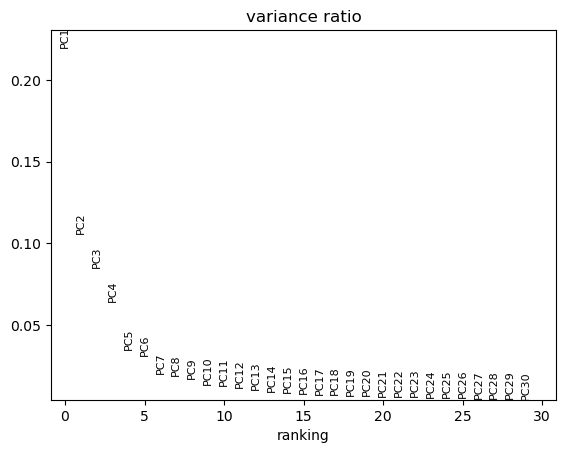

In [10]:
# PCA (on LFC of all HVGs)
sc.pp.pca(log_fold_change_adata_hvg, n_comps=30)
sc.pl.pca_variance_ratio(log_fold_change_adata_hvg, n_pcs=30, log=False)

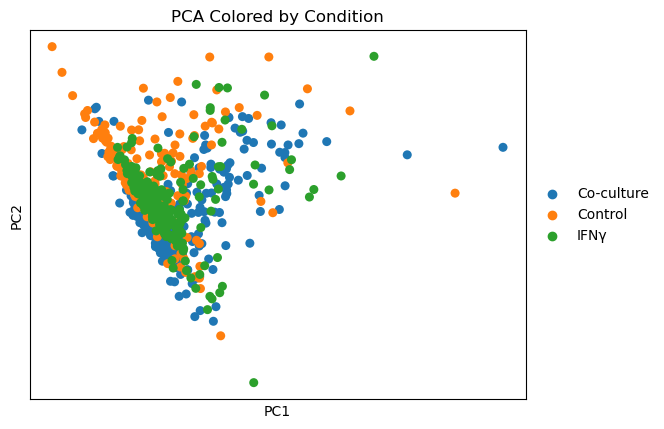

In [11]:
# reduce to 7 PCAs
sc.pp.pca(log_fold_change_adata_hvg, n_comps=7)
sc.pl.pca(log_fold_change_adata_hvg, color='condition', title="PCA Colored by Condition")

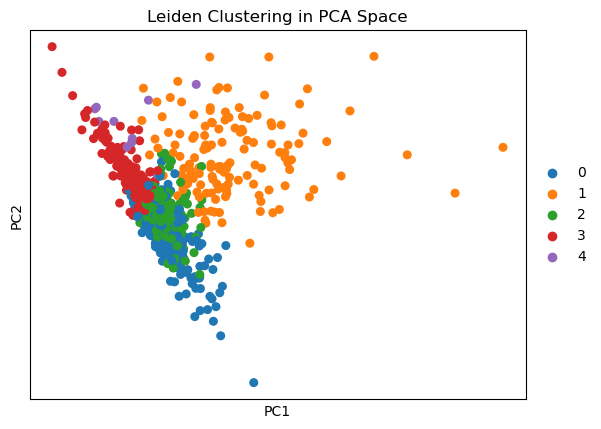

In [12]:
# Neighbors & Leiden Clustering
sc.pp.neighbors(log_fold_change_adata_hvg, use_rep='X_pca')
sc.tl.leiden(log_fold_change_adata_hvg, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

sc.pl.pca(log_fold_change_adata_hvg, color='leiden', title="Leiden Clustering in PCA Space")

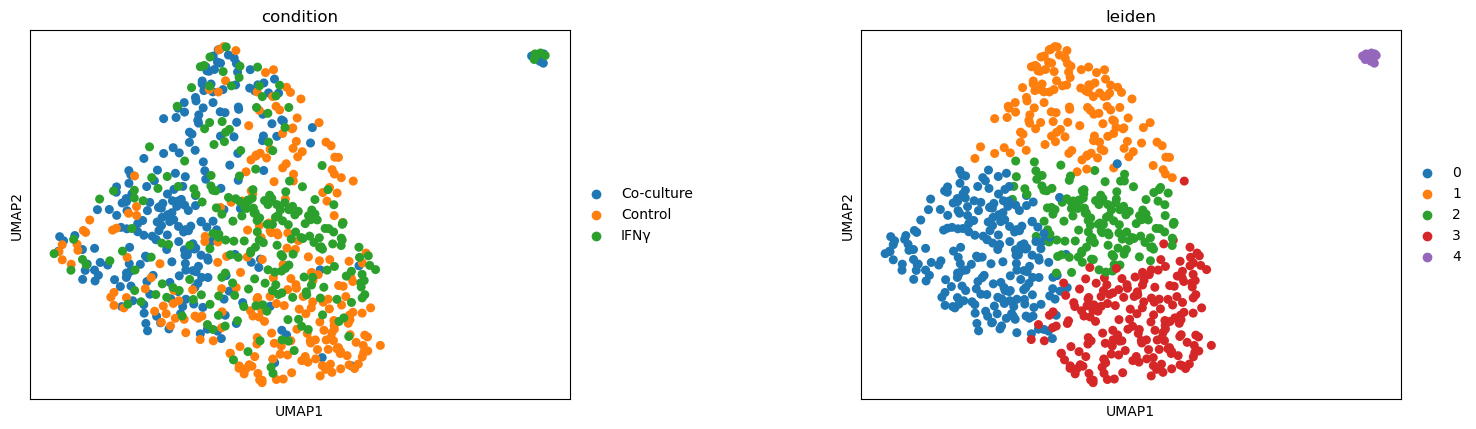

In [13]:
# UMAP (on PCs)
sc.tl.umap(log_fold_change_adata_hvg)
sc.pl.umap(log_fold_change_adata_hvg, color=['condition', 'leiden'], wspace=0.4)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

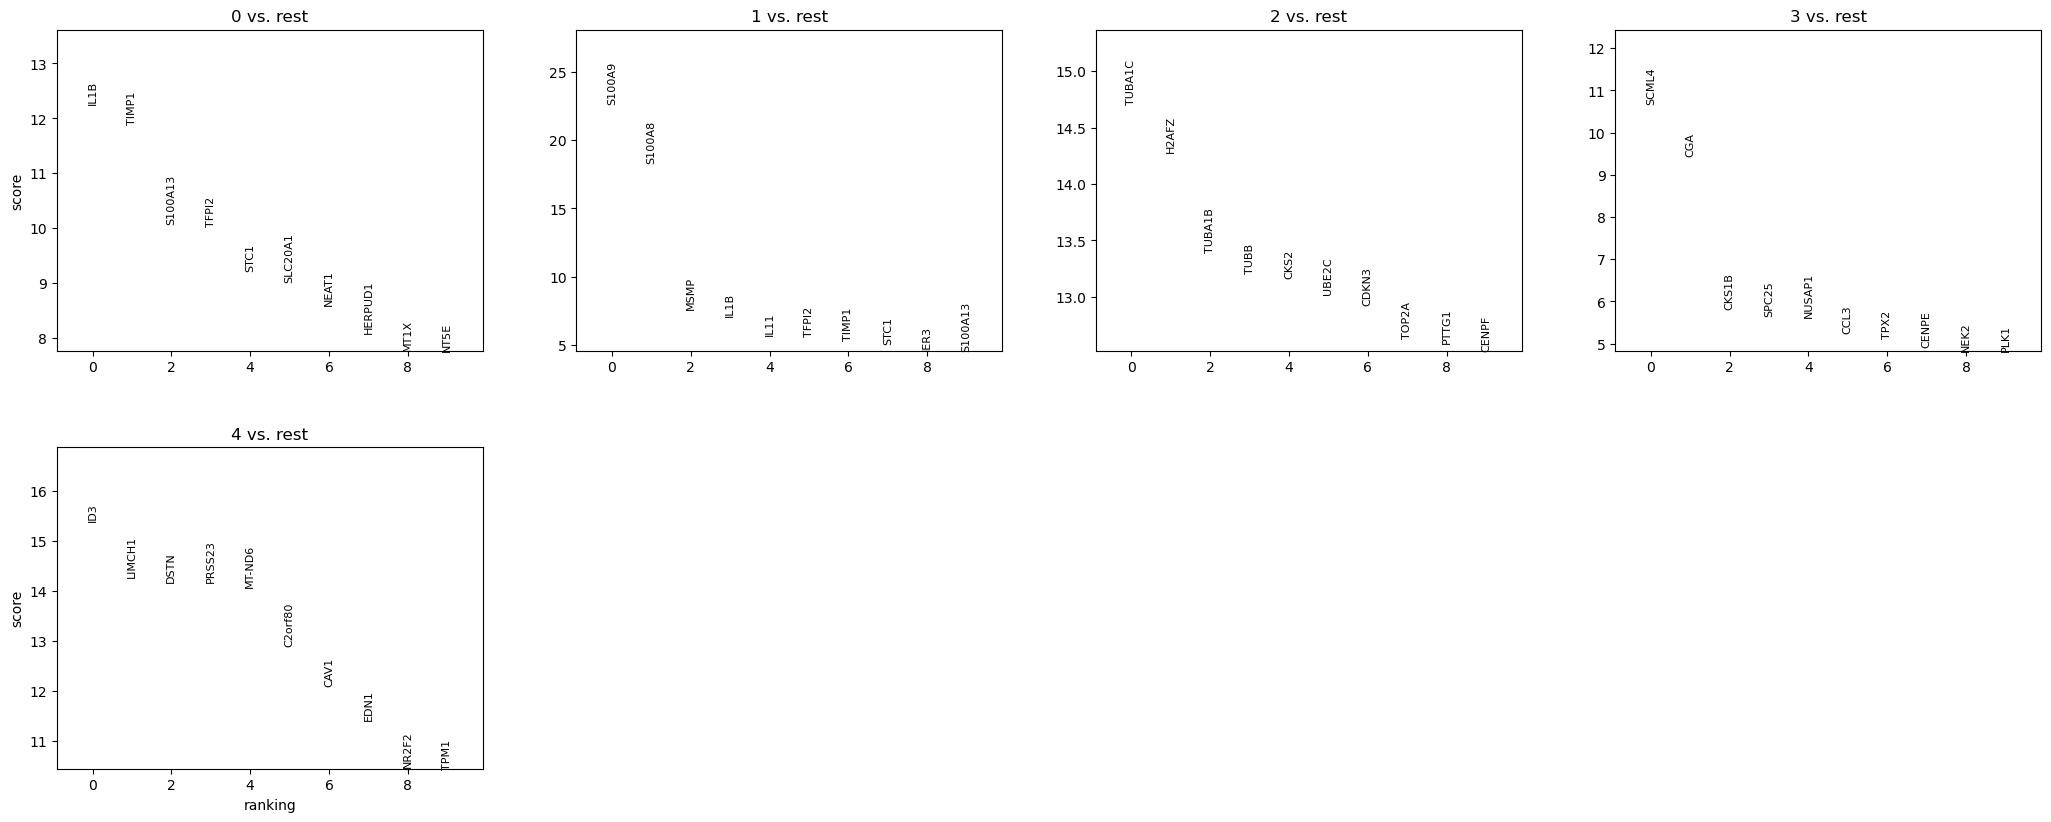

In [14]:
# driver genes 
# genes, which LFC values are most specific for a leiden cluster
log_fold_change_adata_hvg.obs['leiden'] = log_fold_change_adata_hvg.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(log_fold_change_adata_hvg, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(log_fold_change_adata_hvg, n_genes=10, sharey=False)

In [15]:
# pertubations
for cluster_id in log_fold_change_adata_hvg.obs['leiden'].unique():
    perts = log_fold_change_adata_hvg.obs[log_fold_change_adata_hvg.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 224) ---
['A2M', 'ACSL3', 'AGA', 'AHNAK', 'APOE', 'ATP1B1', 'BOLA2B', 'C1QBP', 'CCND1', 'CCR10', 'CCT3', 'CD44', 'CD151', 'CDK4', 'CDK6']

--- Cluster 2 (Total: 148) ---
['ACTA2', 'APOC2', 'C6orf226', 'CD274', 'CHCHD2', 'CMSS1', 'CTSD', 'EIF3K', 'EVA1A', 'HLA-H', 'KCNN4', 'MRPL47', 'PPIA', 'PSAP', 'SPESP1']

--- Cluster 1 (Total: 140) ---
['AEBP1', 'AHCY', 'APOD', 'ARMC6', 'B2M', 'BOLA2', 'BZW2', 'C19orf48', 'CCND2', 'CD47', 'CD58', 'CD59', 'CD63', 'CDC123', 'CDH19']

--- Cluster 3 (Total: 189) ---
['ATP5MD', 'FBL', 'NOLC1', 'P2RX4', 'PPA1', 'PRELID3B', 'RUVBL2', 'SMAD3', 'TMEM173', 'TP53', 'TXNDC17', 'UQCRH', 'ACTA2', 'APOC2', 'ATP1B1']

--- Cluster 4 (Total: 10) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1', 'IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']


## clustering per condition

### 1. control

In [16]:
lfc_control = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Control'].copy()

In [17]:
print(lfc_control)

AnnData object with n_obs × n_vars = 237 × 2000
    obs: 'condition', 'perturbation', 'n_obs_aggregated', 'leiden'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'pca', 'condition_colors', 'neighbors', 'leiden', 'leiden_colors', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


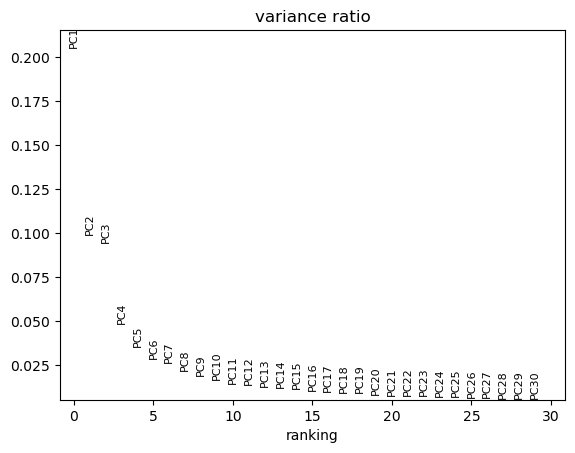

In [18]:
# PCA, find righ amount of PCs
sc.pp.pca(lfc_control, n_comps=30)
sc.pl.pca_variance_ratio(lfc_control, n_pcs=30, log=False)

In [19]:
# reduce to 8 PCAs and compute neighbors and leiden clustering
sc.pp.pca(lfc_control, n_comps=8)
sc.pp.neighbors(lfc_control, use_rep='X_pca')
sc.tl.leiden(lfc_control, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

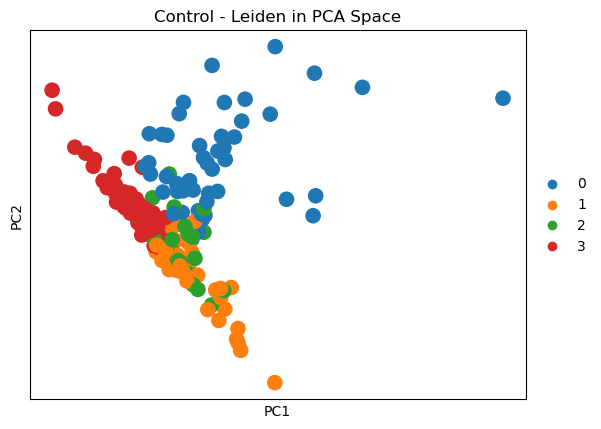

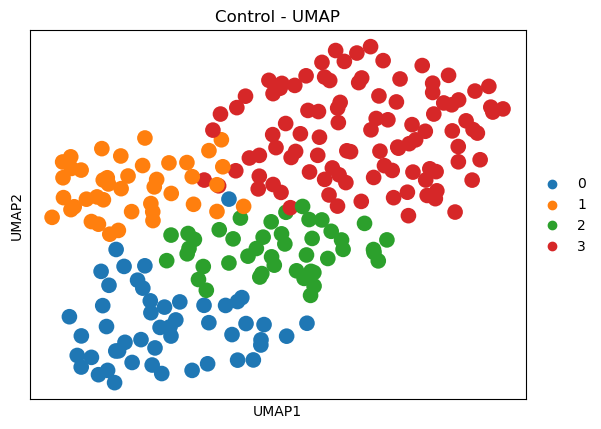

In [20]:
# visualization 
sc.pl.pca(lfc_control, color='leiden', title="Control - Leiden in PCA Space")
sc.tl.umap(lfc_control)
sc.pl.umap(lfc_control, color='leiden', title="Control - UMAP")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


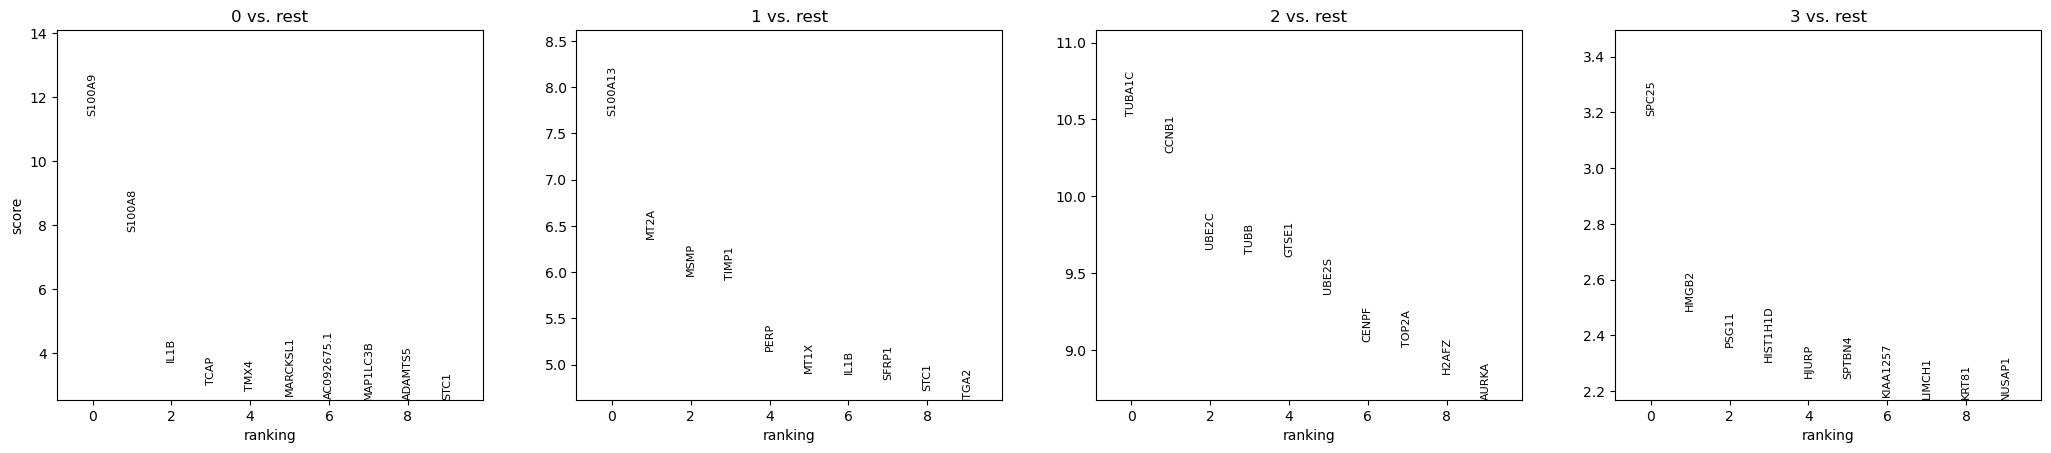

In [21]:
# driver genes 
lfc_control.obs['leiden'] = lfc_control.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(lfc_control, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(lfc_control, n_genes=10, sharey=False)

In [22]:
# pertubations
for cluster_id in lfc_control.obs['leiden'].unique():
    perts = lfc_control.obs[lfc_control.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 50) ---
['A2M', 'AGA', 'AHCY', 'APOE', 'ARMC6', 'BOLA2B', 'BZW2', 'C19orf48', 'CDKN2B', 'CORO1A', 'CTSL', 'DDX17', 'DLL3', 'E2F1', 'FGFR1']

--- Cluster 1 (Total: 42) ---
['ACSL3', 'B2M', 'BOLA2', 'CCND1', 'CCT3', 'CD63', 'CD274', 'CDK4', 'CDK6', 'CKS1B', 'CMSS1', 'CST3', 'CTSA', 'DAG1', 'EEA1']

--- Cluster 2 (Total: 44) ---
['ACTA2', 'AEBP1', 'AHNAK', 'APOD', 'CCND2', 'CD47', 'CD59', 'CDH19', 'CDKN1A', 'CDKN2A', 'CITED1', 'CSPG4', 'CTPS1', 'CTSB', 'CTSD']

--- Cluster 3 (Total: 101) ---
['APOC2', 'ATP1B1', 'ATP5MD', 'C1QBP', 'C6orf226', 'CCR10', 'CD44', 'CD58', 'CD151', 'CDC123', 'CGAS', 'CHCHD2', 'CTSO', 'CYP27A1', 'DDR1']


### 2. IFN-gamma

In [23]:
lfc_IFN_gamma = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'IFNγ'].copy()

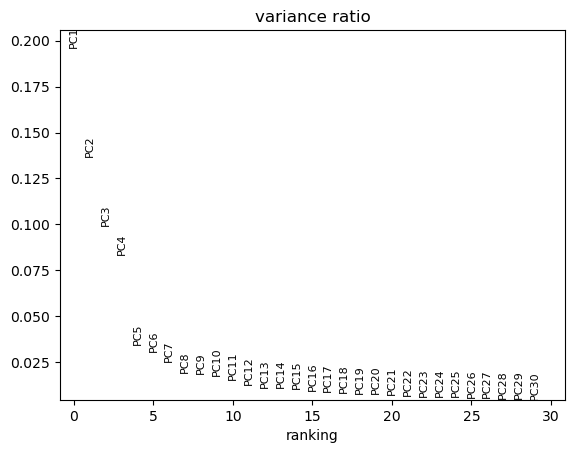

In [24]:
# PCA, find righ amount of PCs
sc.pp.pca(lfc_IFN_gamma, n_comps=30)
sc.pl.pca_variance_ratio(lfc_IFN_gamma, n_pcs=30, log=False)

In [25]:
# reduce to 5 PCAs and compute neighbors and leiden clustering
sc.pp.pca(lfc_IFN_gamma, n_comps=5)
sc.pp.neighbors(lfc_IFN_gamma, use_rep='X_pca')
sc.tl.leiden(lfc_IFN_gamma, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

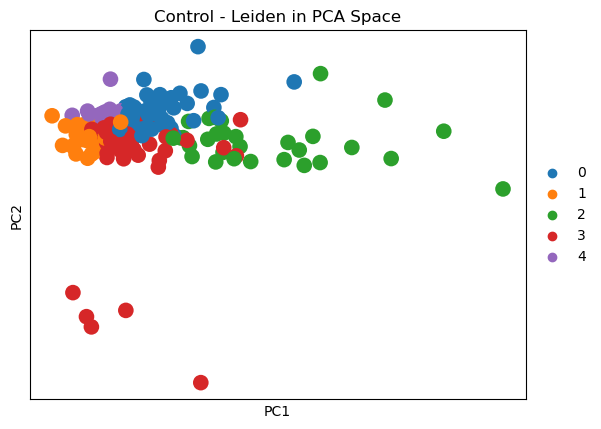

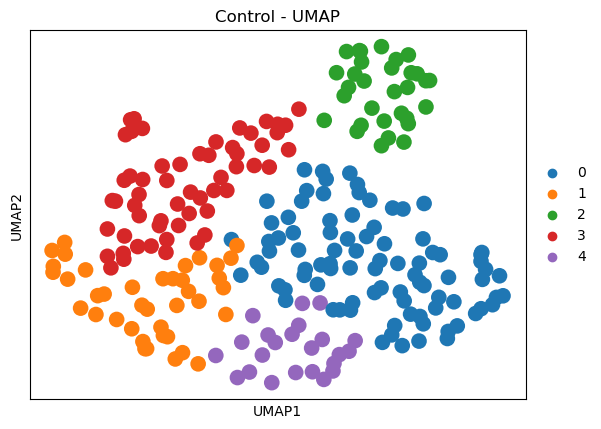

In [26]:
# visualization 
sc.pl.pca(lfc_IFN_gamma, color='leiden', title="IFNY - Leiden in PCA Space")
sc.tl.umap(lfc_IFN_gamma)
sc.pl.umap(lfc_IFN_gamma, color='leiden', title="IFNY - UMAP")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

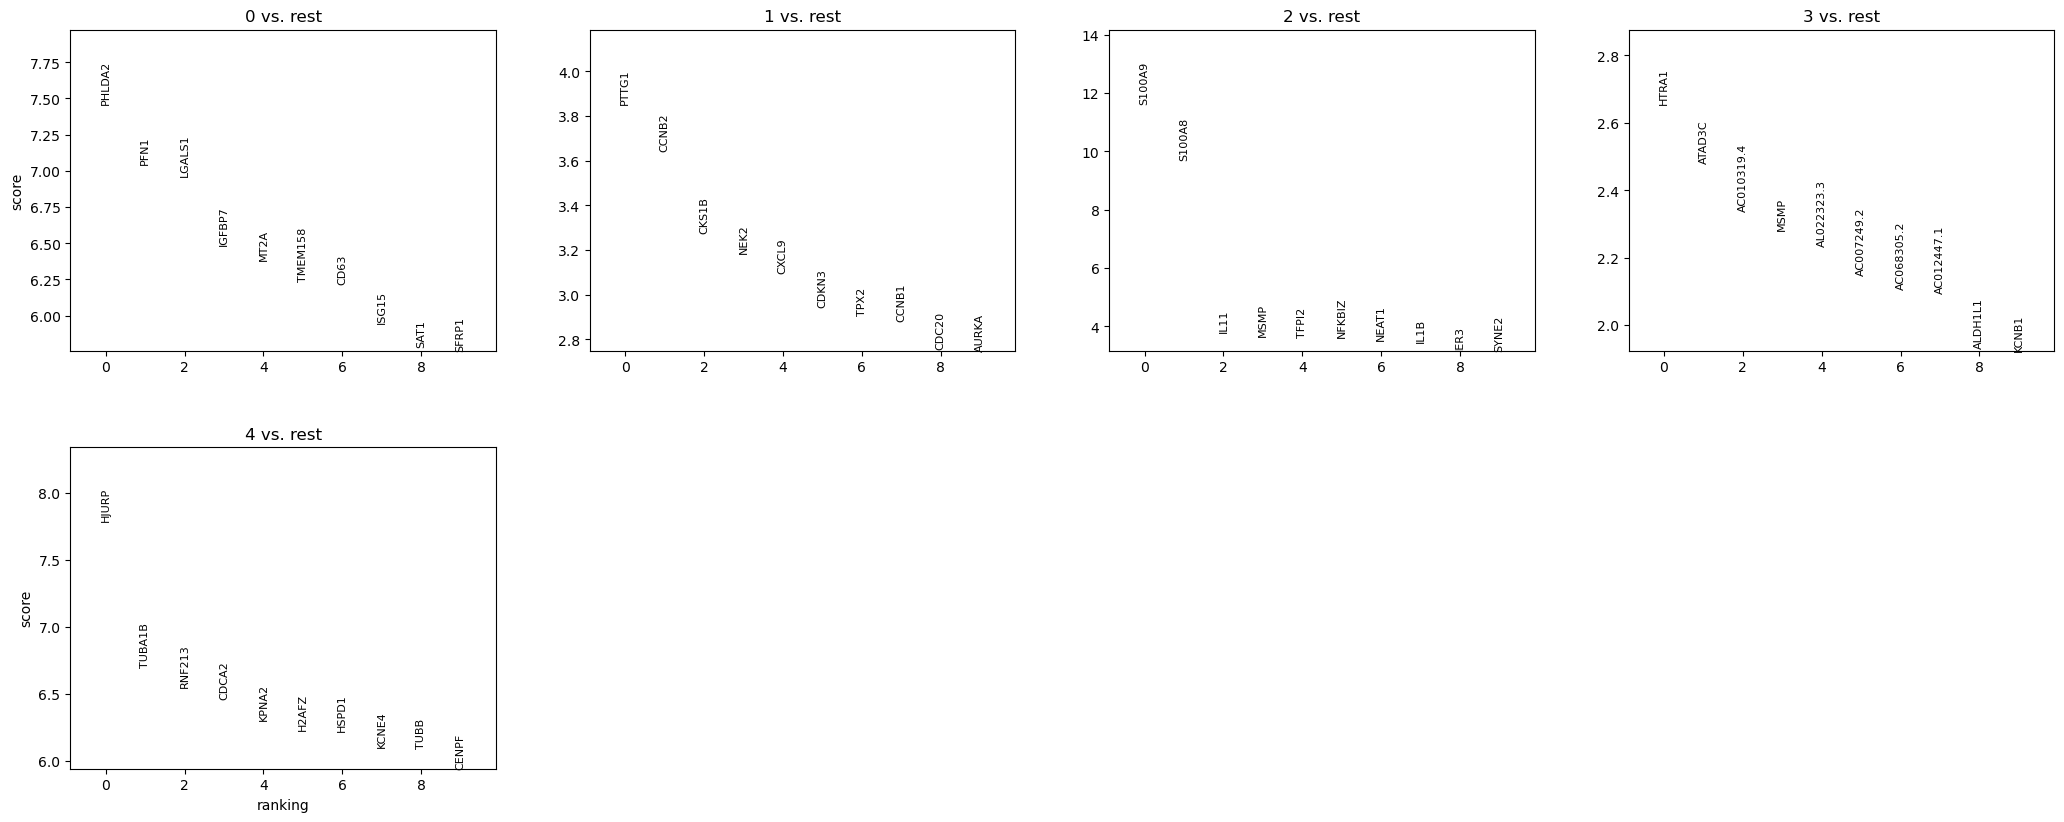

In [27]:
# driver genes 
lfc_IFN_gamma.obs['leiden'] = lfc_IFN_gamma.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(lfc_IFN_gamma, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(lfc_IFN_gamma, n_genes=10, sharey=False)

In [28]:
# pertubations
for cluster_id in lfc_IFN_gamma.obs['leiden'].unique():
    perts = lfc_IFN_gamma.obs[lfc_IFN_gamma.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 88) ---
['A2M', 'ACTA2', 'AGA', 'AHCY', 'AHNAK', 'APOC2', 'APOE', 'ATP1B1', 'B2M', 'BOLA2', 'BZW2', 'C6orf226', 'C19orf48', 'CCND1', 'CD44']

--- Cluster 2 (Total: 31) ---
['ACSL3', 'AEBP1', 'APOD', 'C1QBP', 'CCND2', 'CD47', 'CDKN1A', 'CITED1', 'CMSS1', 'CTPS1', 'DAG1', 'DDR1', 'DDX39A', 'EEF1G', 'EIF3K']

--- Cluster 1 (Total: 39) ---
['ARMC6', 'ATP5MD', 'CCR10', 'CD58', 'CGAS', 'EEA1', 'EMP1', 'GAA', 'HLA-E', 'HLA-H', 'HNRNPA1', 'HSPA1A', 'ITGA3', 'KCNN4', 'KDR']

--- Cluster 3 (Total: 56) ---
['BOLA2B', 'CCT3', 'CD63', 'EVA1A', 'GSEC', 'HASPIN', 'HNRNPC', 'IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'JMJD7', 'KLF4', 'LCP1', 'LINC00518']

--- Cluster 4 (Total: 23) ---
['CTSA', 'CXCR4', 'DDX17', 'DLL3', 'FOXM1', 'HLA-C', 'HLA-DRB5', 'IDH2', 'IDI2-AS1', 'IRF3', 'ISYNA1', 'LRPAP1', 'MT2A', 'NPC1', 'PSAP']


### 3. co-culture

In [29]:
lfc_co_culture = log_fold_change_adata_hvg[log_fold_change_adata_hvg.obs['condition'] == 'Co-culture'].copy()

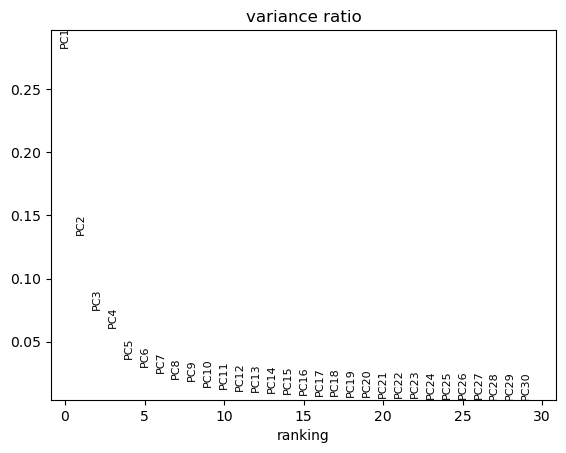

In [30]:
# PCA, find righ amount of PCs
sc.pp.pca(lfc_co_culture, n_comps=30)
sc.pl.pca_variance_ratio(lfc_co_culture, n_pcs=30, log=False)

In [31]:
# reduce to 8 PCAs and compute neighbors and leiden clustering
sc.pp.pca(lfc_co_culture, n_comps=8)
sc.pp.neighbors(lfc_co_culture, use_rep='X_pca')
sc.tl.leiden(lfc_co_culture, resolution=0.5, key_added='leiden', flavor='igraph', n_iterations=2)

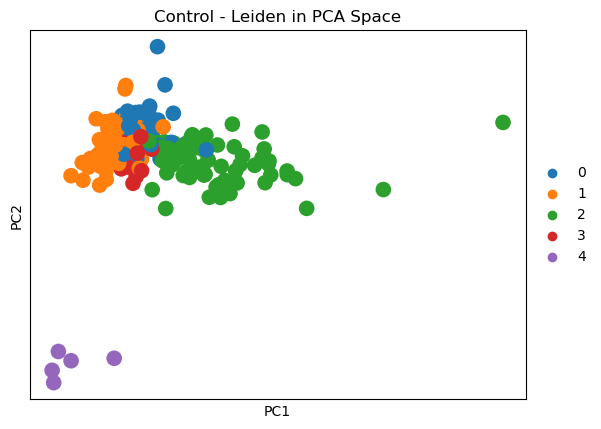

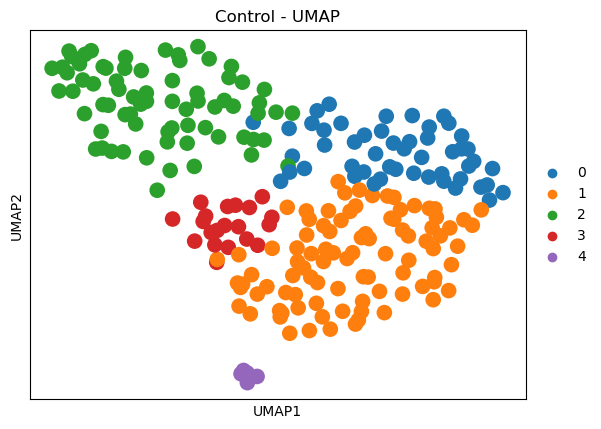

In [32]:
# visualization 
sc.pl.pca(lfc_co_culture, color='leiden', title="Co-culture - Leiden in PCA Space")
sc.tl.umap(lfc_co_culture)
sc.pl.umap(lfc_co_culture, color='leiden', title="Co-culture - UMAP")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

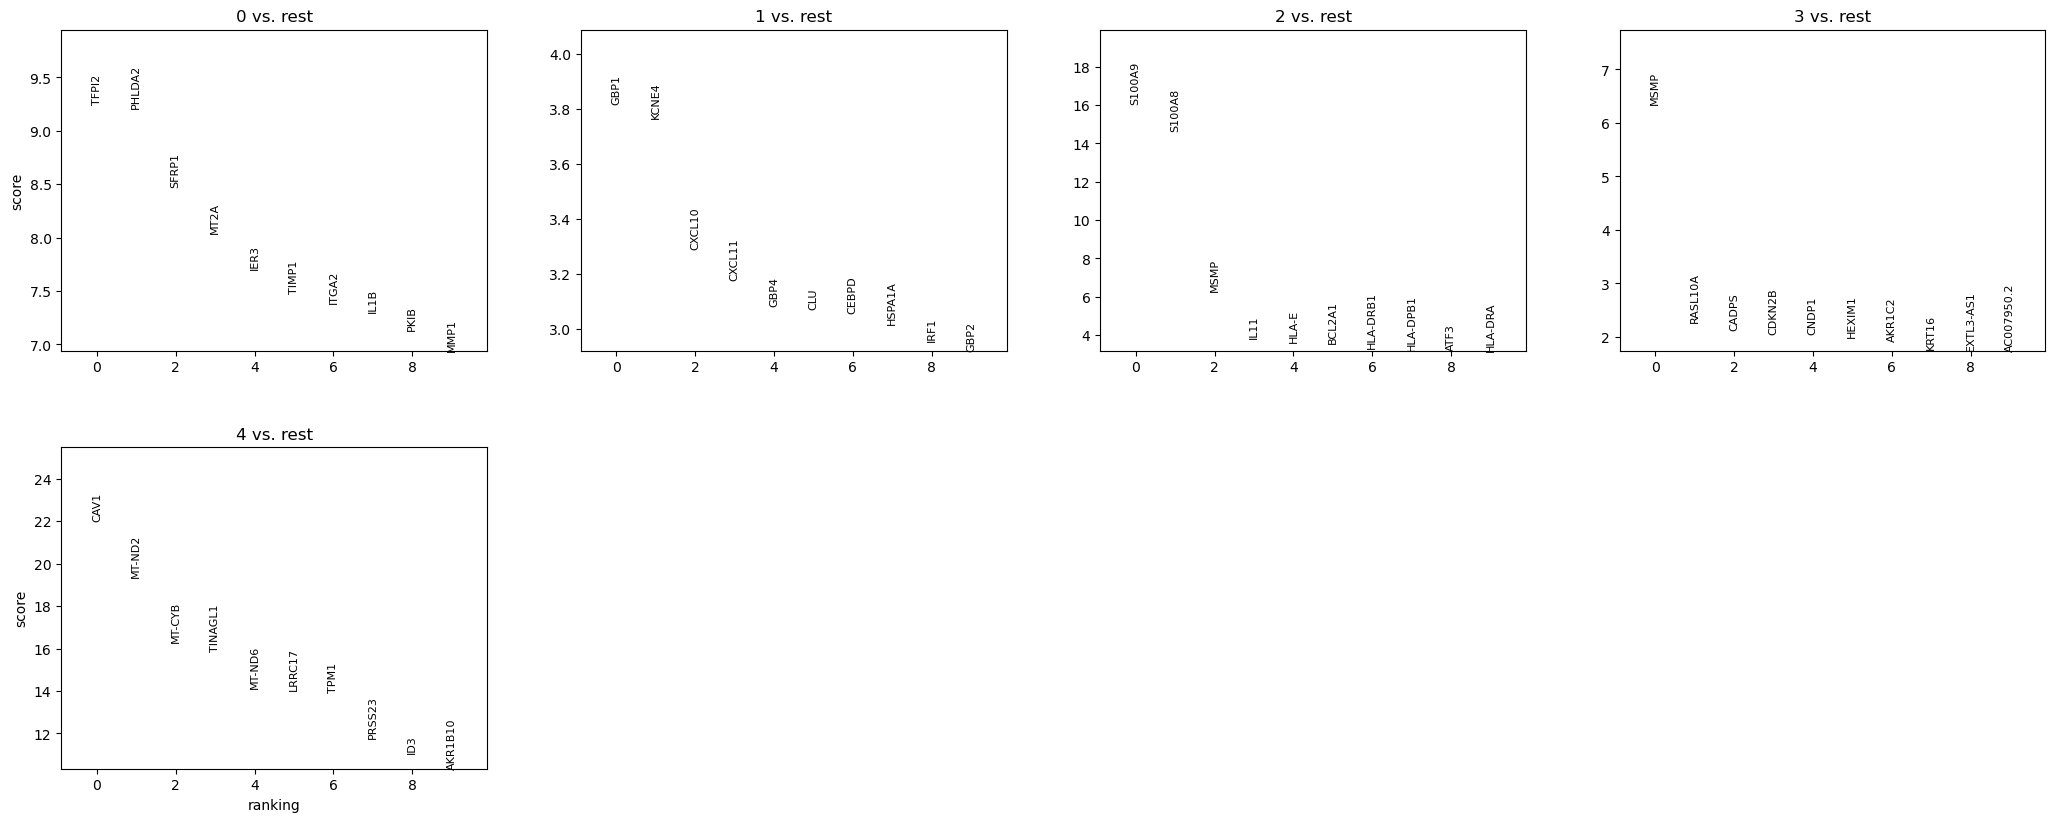

In [33]:
# driver genes 
lfc_co_culture.obs['leiden'] = lfc_co_culture.obs['leiden'].astype('category')
sc.tl.rank_genes_groups(lfc_co_culture, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(lfc_co_culture, n_genes=10, sharey=False)

In [34]:
# pertubations
for cluster_id in lfc_co_culture.obs['leiden'].unique():
    perts = lfc_co_culture.obs[lfc_co_culture.obs['leiden'] == cluster_id]['perturbation'].tolist()
    print(f"\n--- Cluster {cluster_id} (Total: {len(perts)}) ---")
    print(perts[:15])


--- Cluster 0 (Total: 50) ---
['A2M', 'ACSL3', 'AHNAK', 'APOC2', 'ATP1B1', 'BOLA2B', 'CCT3', 'CDK6', 'CDKN2A', 'CDKN2B', 'CHCHD2', 'CKS1B', 'CMSS1', 'CORO1A', 'CTSL']

--- Cluster 1 (Total: 91) ---
['ACTA2', 'AGA', 'APOE', 'ATP5MD', 'C6orf226', 'CCND1', 'CCR10', 'CD44', 'CD151', 'CDK4', 'CGAS', 'CST3', 'CTSB', 'DDX17', 'EIF3K']

--- Cluster 2 (Total: 71) ---
['AEBP1', 'AHCY', 'APOD', 'ARMC6', 'B2M', 'BOLA2', 'BZW2', 'C19orf48', 'CCND2', 'CD47', 'CD58', 'CD59', 'CD63', 'CD274', 'CDC123']

--- Cluster 3 (Total: 20) ---
['C1QBP', 'DDR1', 'GPI', 'HLA-C', 'ISYNA1', 'LGALS3', 'NDUFA13', 'NPC2', 'PAICS', 'PIK3IP1', 'PROS1', 'SDC3', 'SHMT2', 'SNHG6', 'SP100']

--- Cluster 4 (Total: 5) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']


## Pathway Analysis

### Define function to conduct the pathway enrichment analysis of upregulated and downregulated driver genes

In [35]:
import gseapy as gp

In [36]:
# define function for pathway analysis 
# see if driver genes per cluster are in a gene group from a pathway 
# either driver genes which have a high lfc or a negative lfc

def pathway_analysis(
    adata, direction="up", gene_sets=None, top_n=50, p_threshold=0.01
):
    if gene_sets is None:
        gene_sets = ["MSigDB_Hallmark_2020", "KEGG_2021_Human"]

    # Driver Genes per cluster
    result_df = sc.get.rank_genes_groups_df(adata, group=None)

    # loop over all leiden clusters
    for cluster_id in adata.obs["leiden"].cat.categories:

        cluster_df = result_df[
            (result_df["group"].astype(str) == str(cluster_id))
            & (result_df["pvals"] < p_threshold)
        ]

        # search for positive lfcs or negative lfcs
        if direction == "down":
            cluster_df = cluster_df.sort_values("scores", ascending=True)
            label = "Downregulated"
        else:
            cluster_df = cluster_df.sort_values("scores", ascending=False)
            label = "Upregulated"

        # extract top n driver genes 
        top_genes = cluster_df.head(top_n)["names"].tolist()

        print(
            f"\n--- Cluster {cluster_id} ({label}): {len(top_genes)} genes found ---"
        )

        if len(top_genes) >= 3:
            # enrichment-analysis with enrichr
            enr = gp.enrichr(
                gene_list=top_genes,
                gene_sets=gene_sets,
                organism="human",
                outdir=None,
            )

            sig_results = enr.results[enr.results["Adjusted P-value"] < 0.05]

            if not sig_results.empty:
                gp.dotplot(
                    sig_results,
                    top_term=10,
                    title=f"Cluster {cluster_id} - {label} Pathways",
                )
                plt.show()
            else:
                print(f"no significant pathway found for cluster {cluster_id}")
        else:
            print(f"not enough genes for cluster {cluster_id}")

### 1. control


--- Cluster 0 (Upregulated): 23 genes found ---


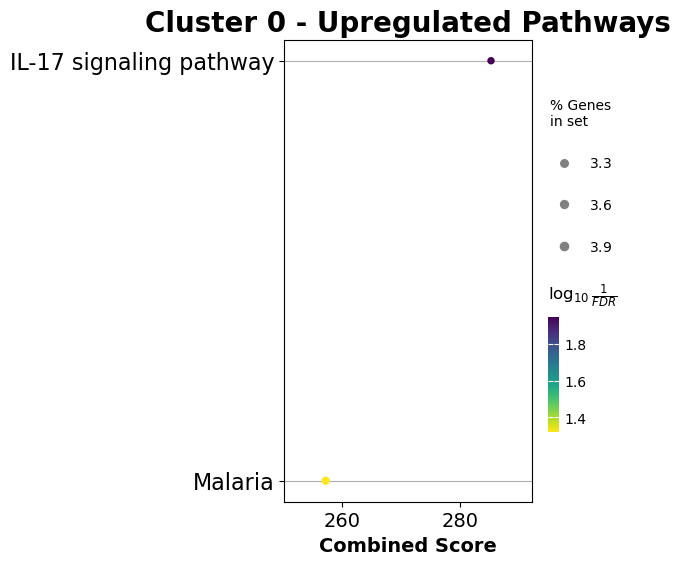


--- Cluster 1 (Upregulated): 50 genes found ---


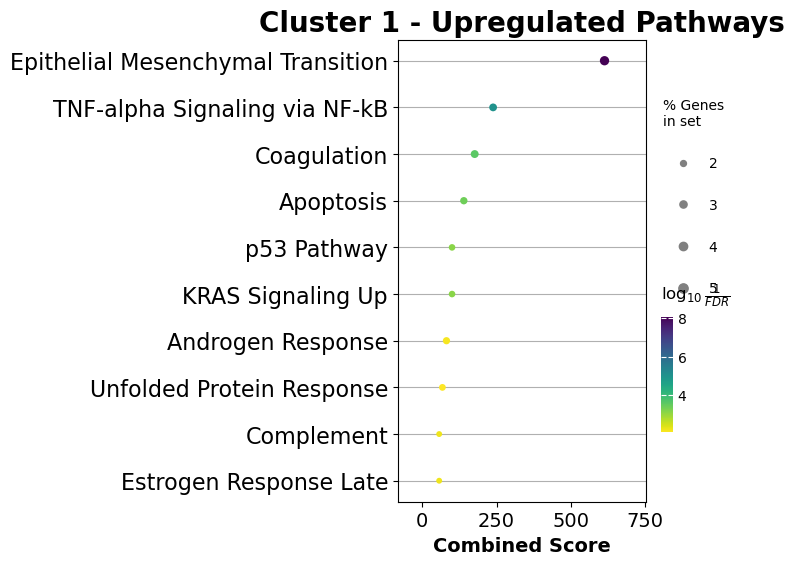


--- Cluster 2 (Upregulated): 50 genes found ---


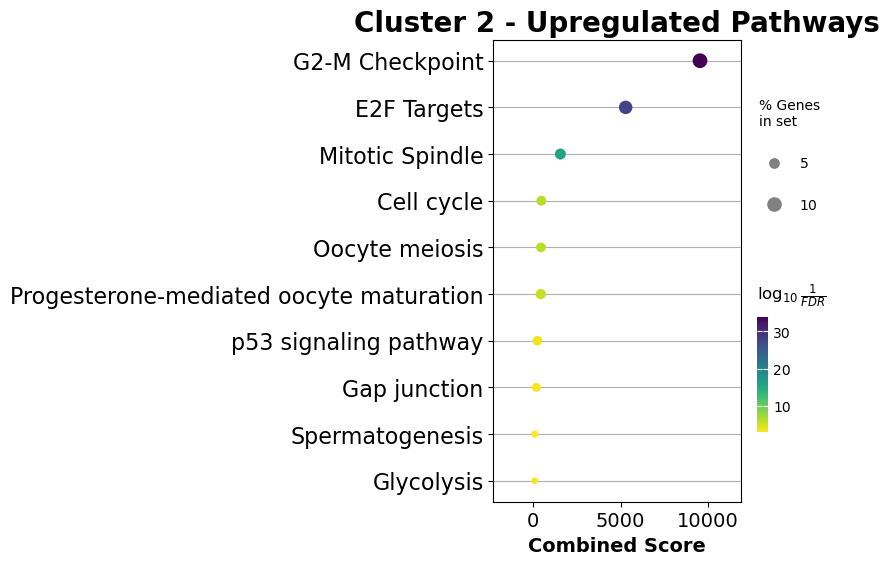


--- Cluster 3 (Upregulated): 50 genes found ---


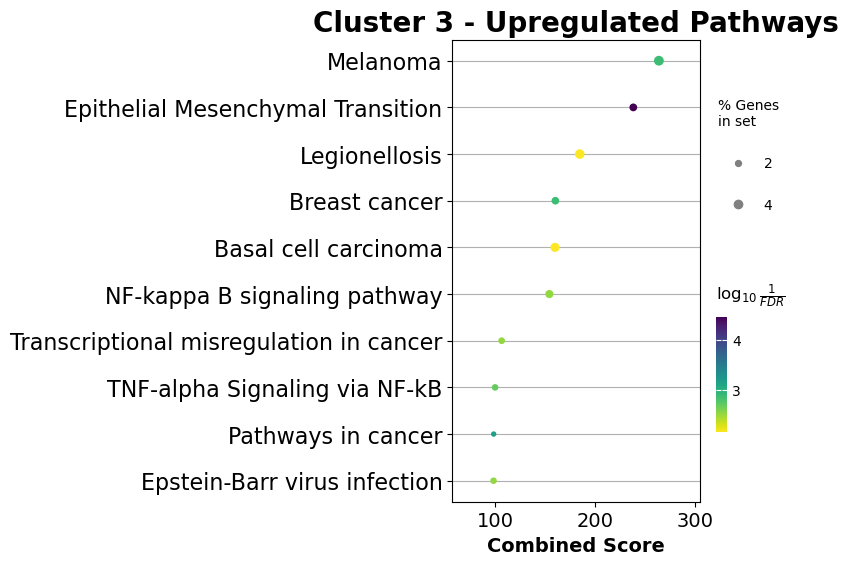


--- Cluster 0 (Downregulated): 23 genes found ---


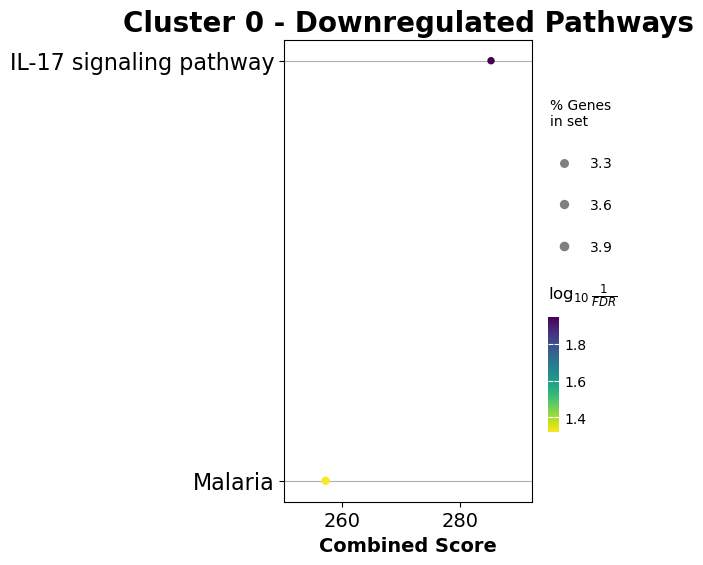


--- Cluster 1 (Downregulated): 50 genes found ---


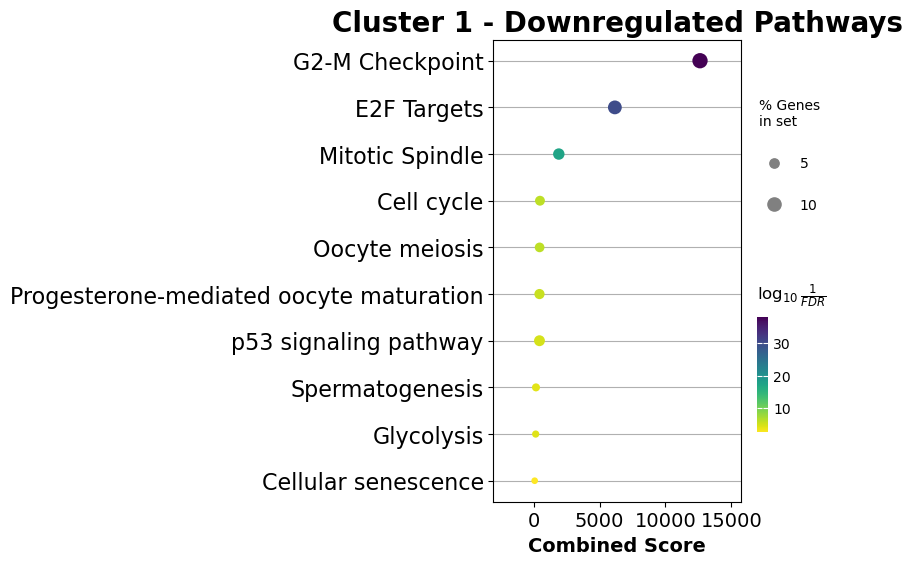


--- Cluster 2 (Downregulated): 50 genes found ---


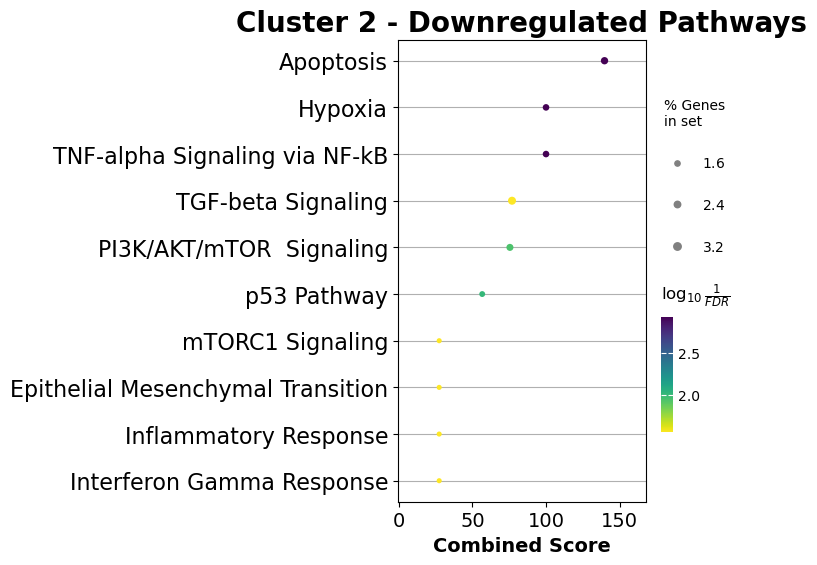


--- Cluster 3 (Downregulated): 50 genes found ---


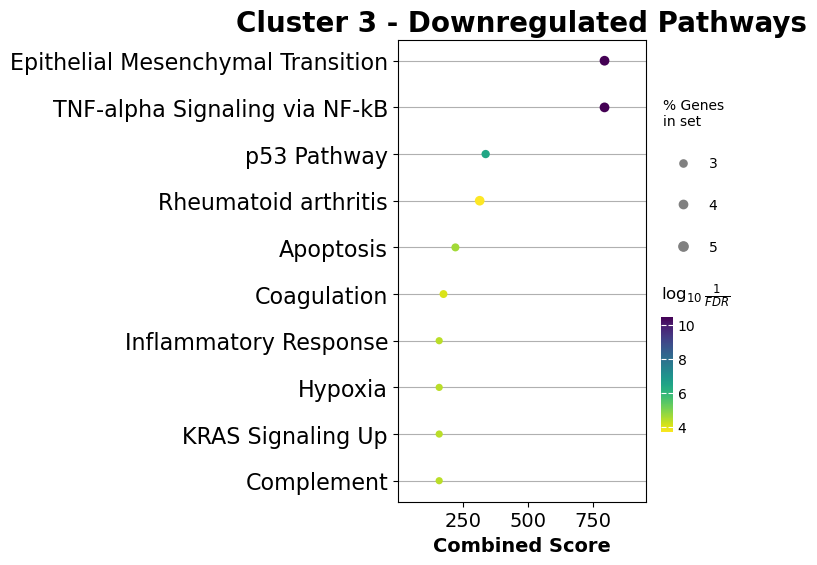

In [37]:
# control
pathway_analysis(lfc_control, direction="up")
pathway_analysis(lfc_control, direction="down")


### 2. IFN-gamma


--- Cluster 0 (Upregulated): 50 genes found ---


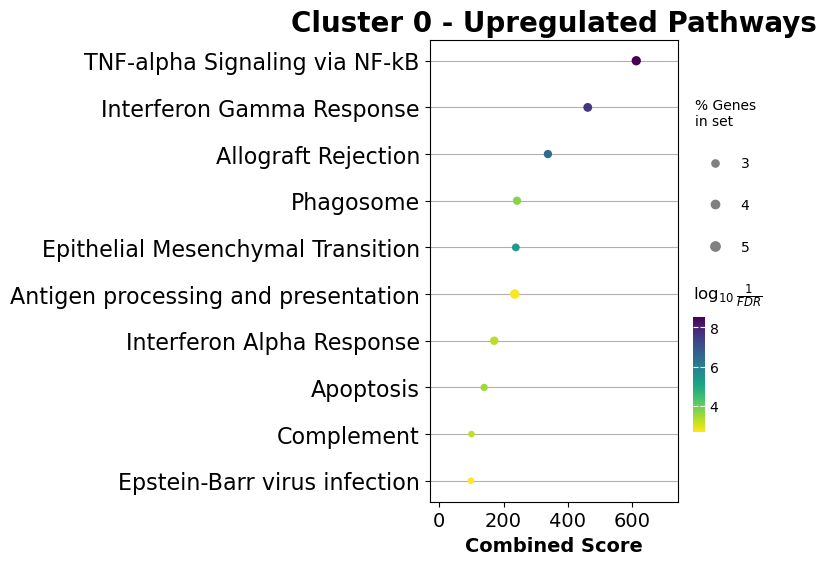


--- Cluster 1 (Upregulated): 50 genes found ---


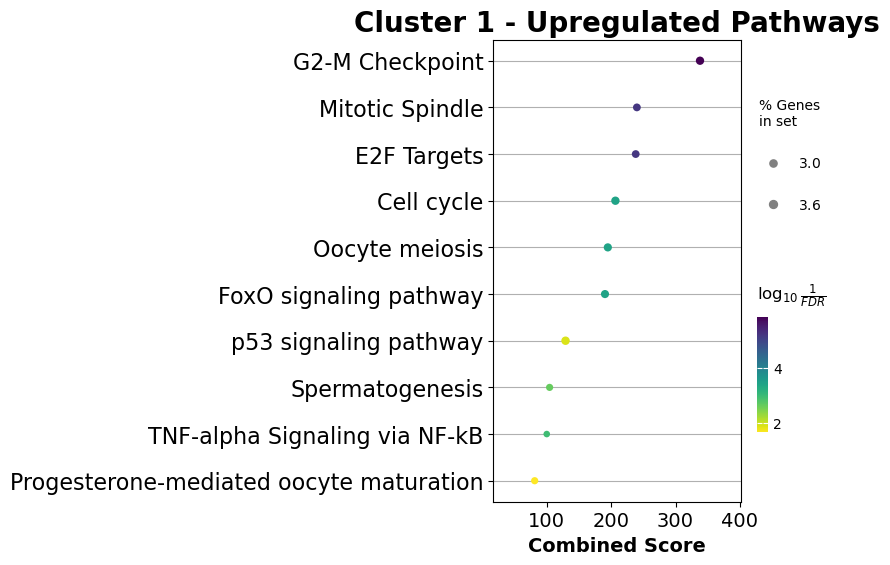


--- Cluster 2 (Upregulated): 50 genes found ---


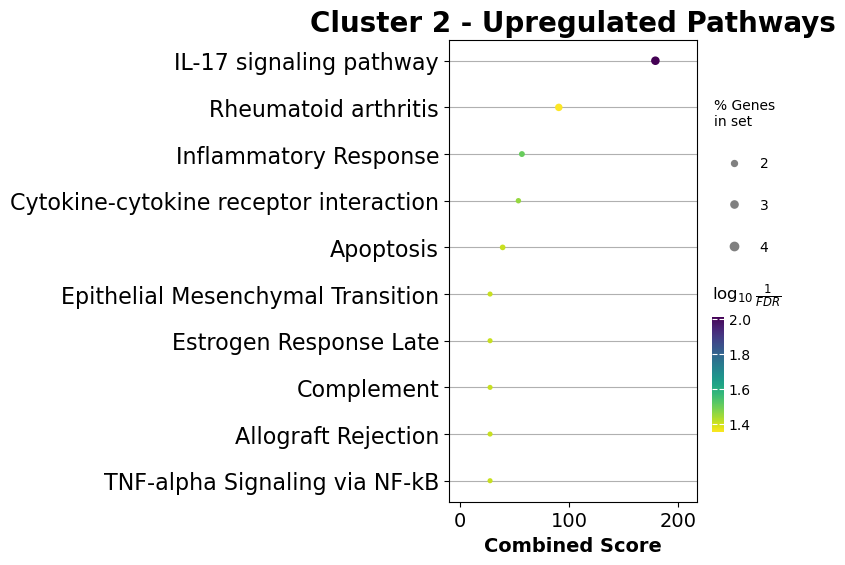


--- Cluster 3 (Upregulated): 50 genes found ---


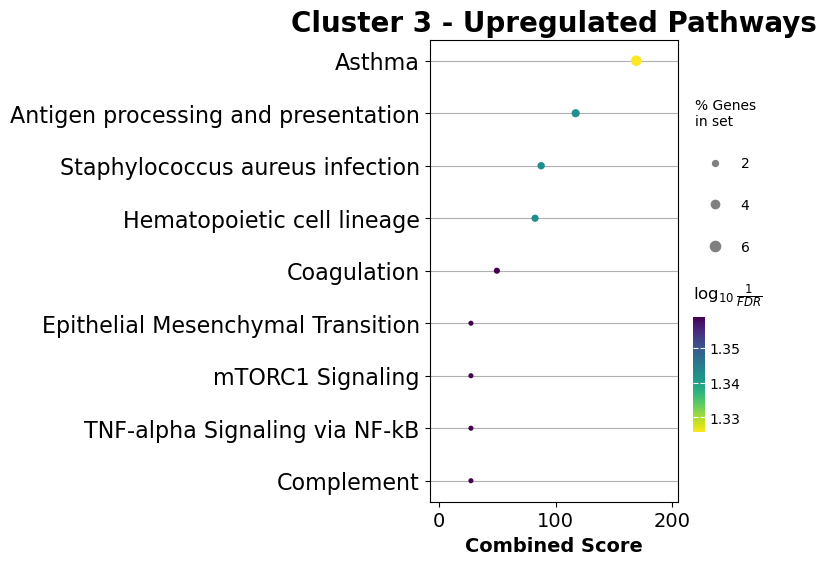


--- Cluster 4 (Upregulated): 50 genes found ---


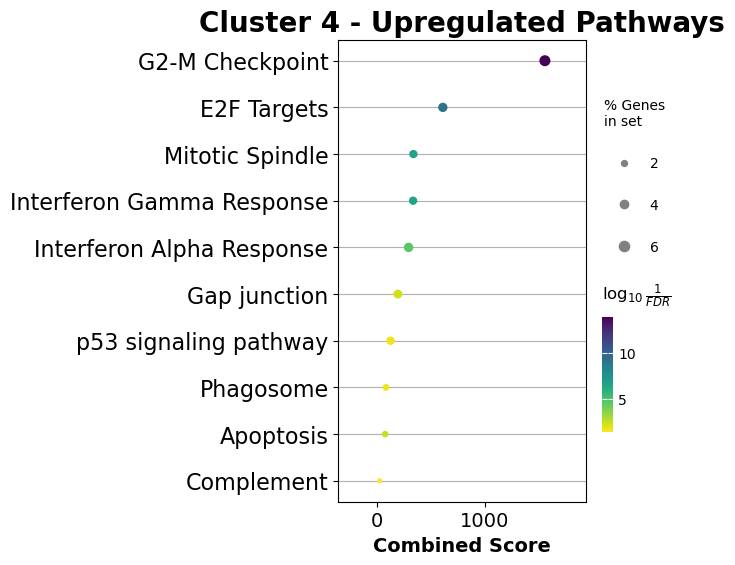


--- Cluster 0 (Downregulated): 50 genes found ---


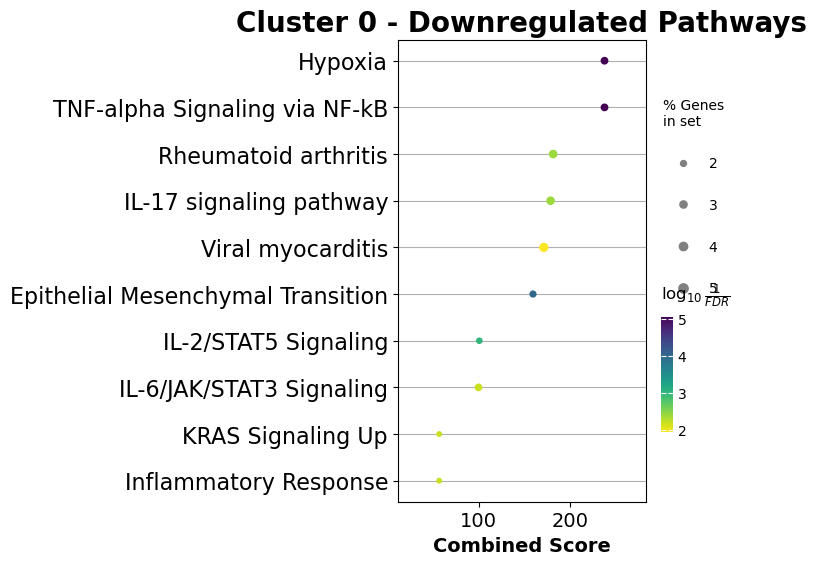


--- Cluster 1 (Downregulated): 50 genes found ---


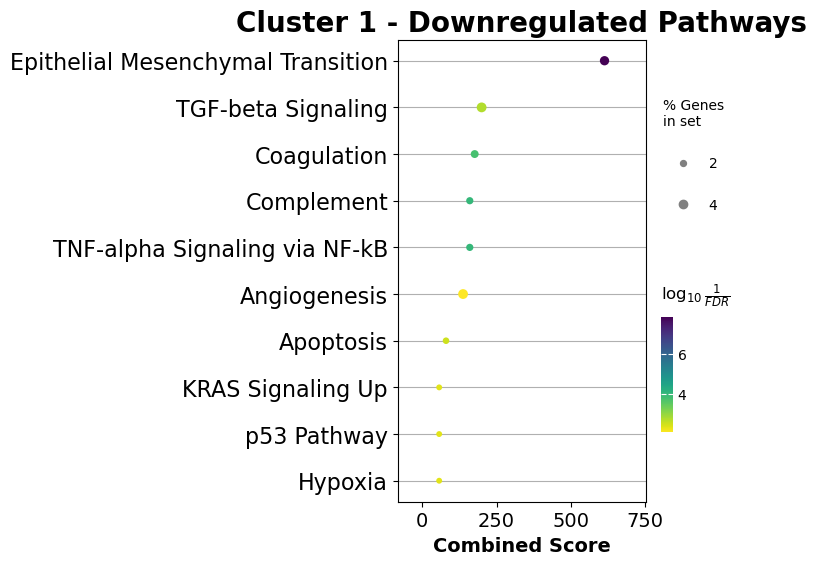


--- Cluster 2 (Downregulated): 50 genes found ---
no significant pathway found for cluster 2

--- Cluster 3 (Downregulated): 50 genes found ---


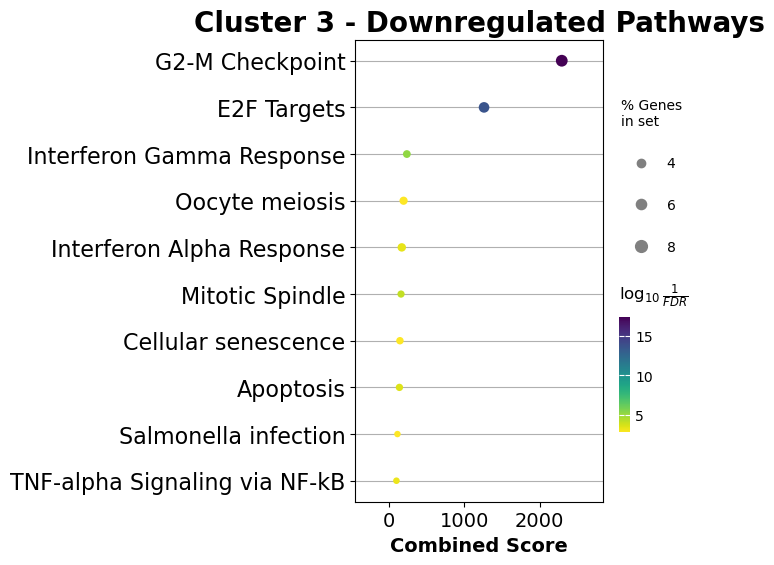


--- Cluster 4 (Downregulated): 50 genes found ---


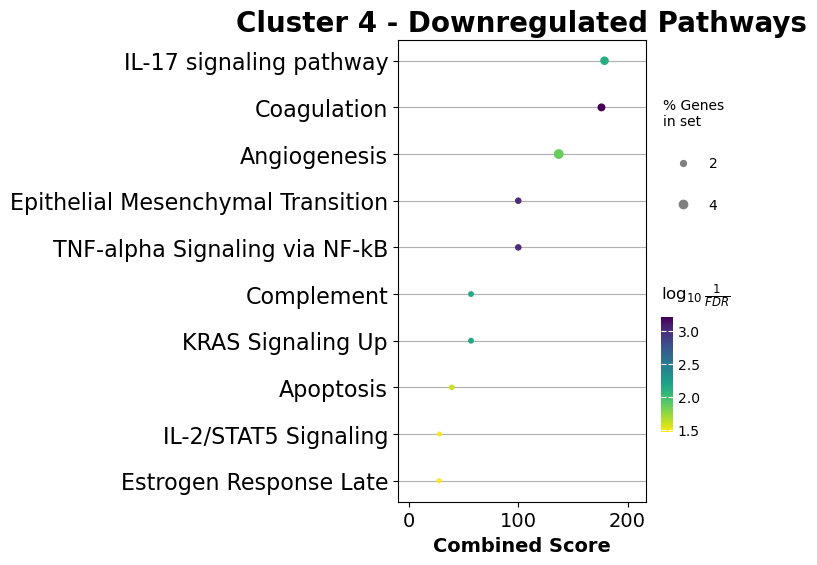

In [38]:
# IFN-gamma 
pathway_analysis(lfc_IFN_gamma, direction="up")
pathway_analysis(lfc_IFN_gamma, direction="down")

### 3. co-culture


--- Cluster 0 (Upregulated): 50 genes found ---


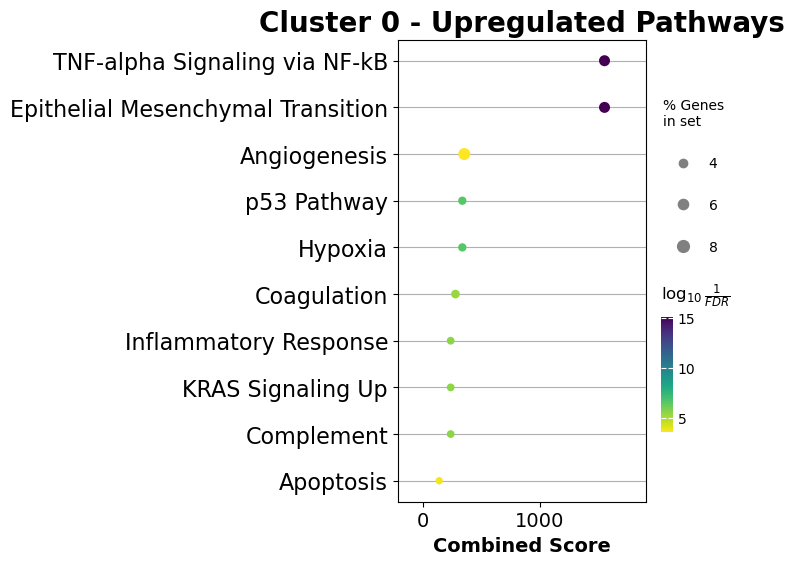


--- Cluster 1 (Upregulated): 50 genes found ---


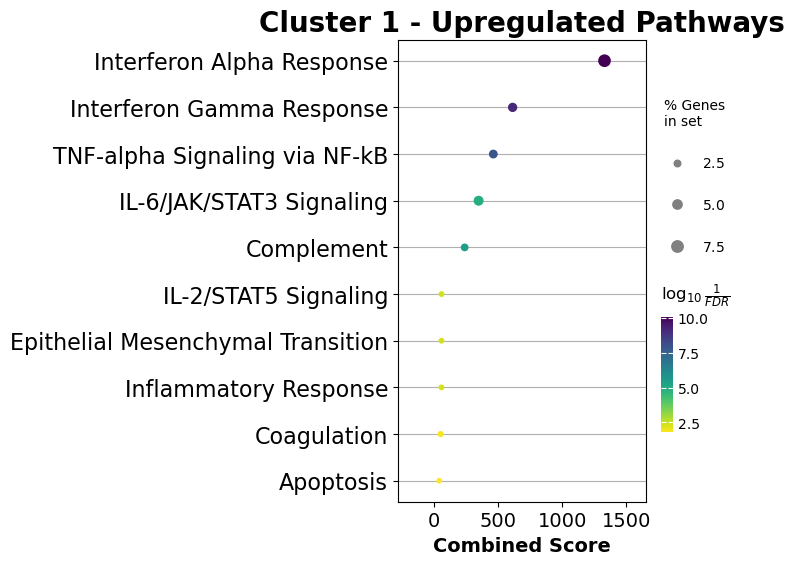


--- Cluster 2 (Upregulated): 31 genes found ---


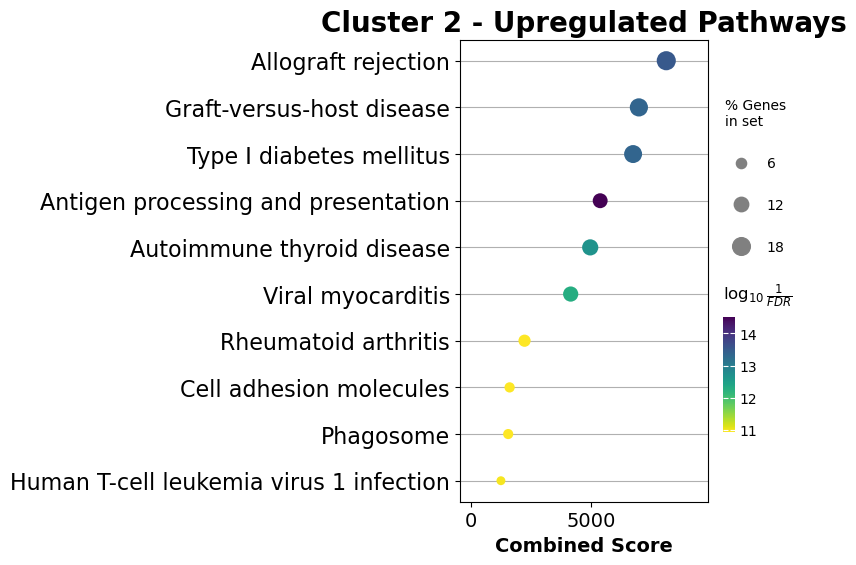


--- Cluster 3 (Upregulated): 50 genes found ---


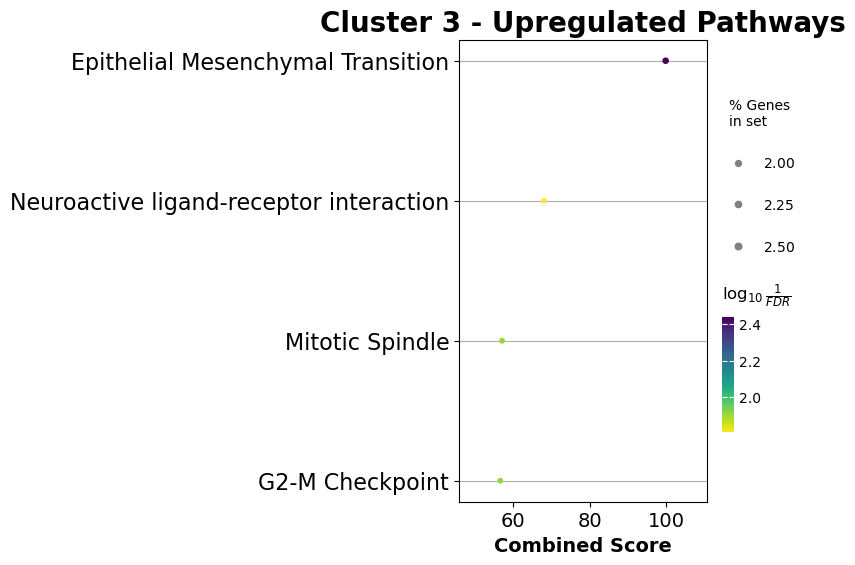


--- Cluster 4 (Upregulated): 50 genes found ---


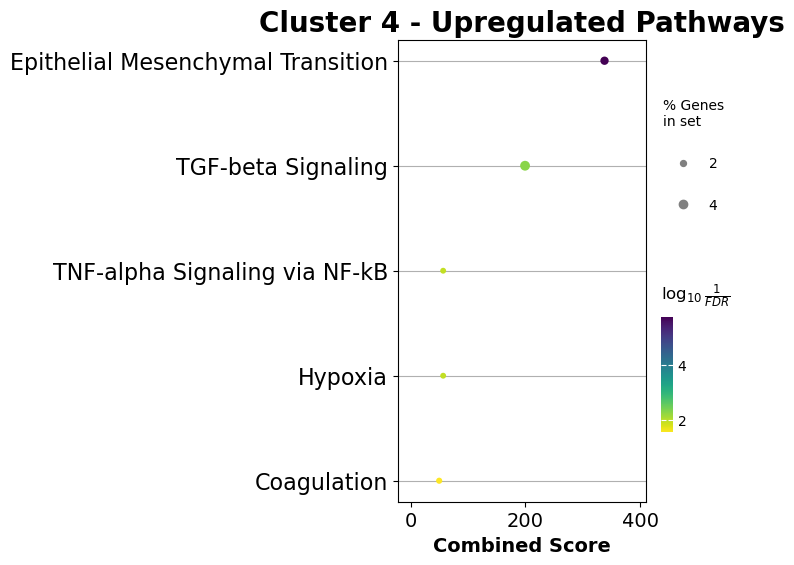


--- Cluster 0 (Downregulated): 50 genes found ---


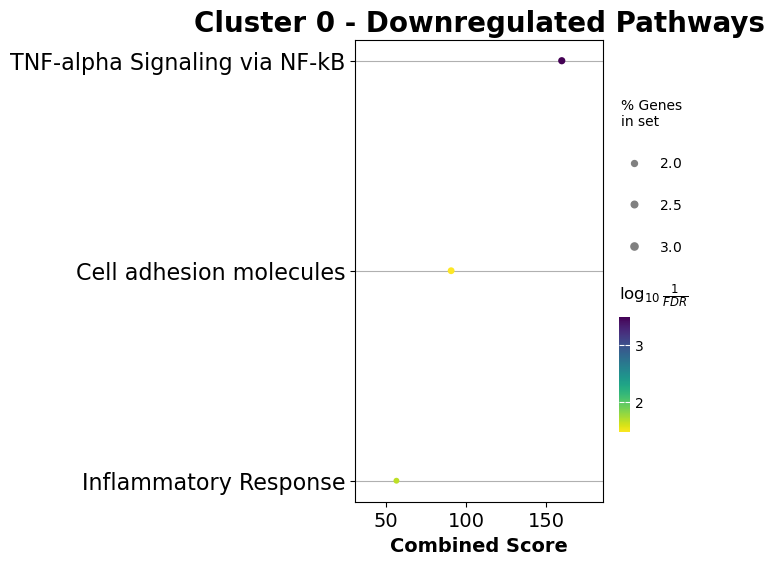


--- Cluster 1 (Downregulated): 50 genes found ---


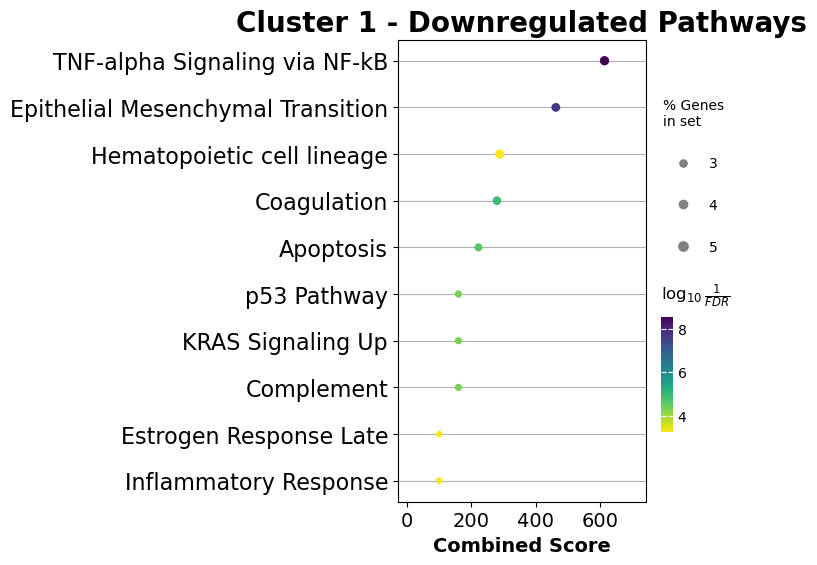


--- Cluster 2 (Downregulated): 31 genes found ---


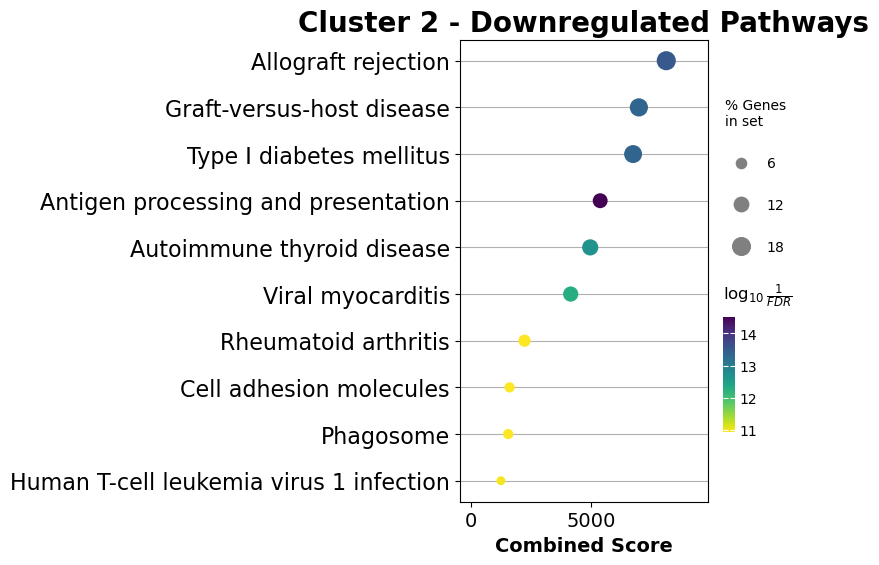


--- Cluster 3 (Downregulated): 50 genes found ---


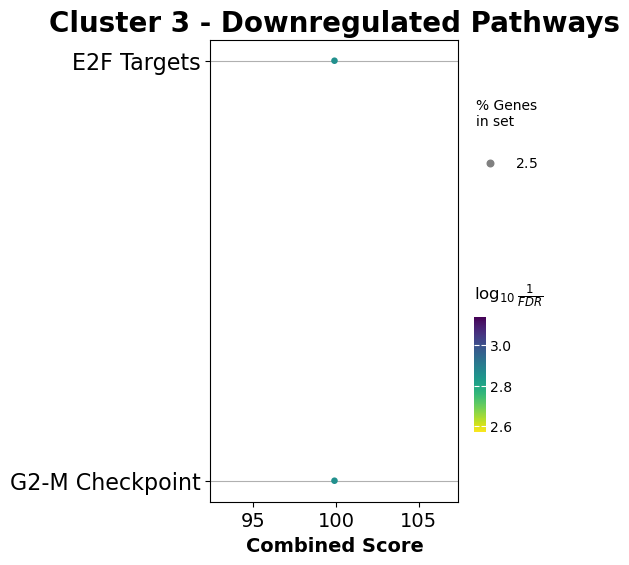


--- Cluster 4 (Downregulated): 50 genes found ---


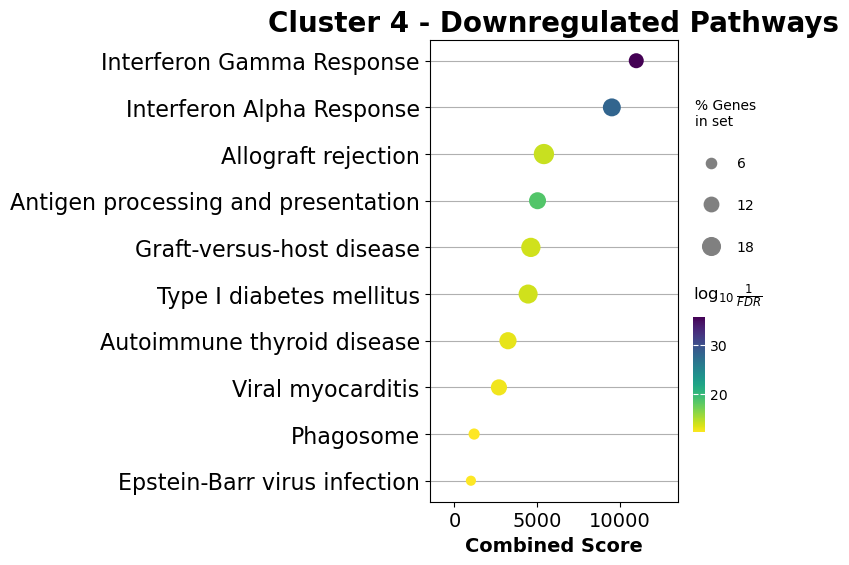

In [39]:
# co-culture 
pathway_analysis(lfc_co_culture, direction="up")
pathway_analysis(lfc_co_culture, direction="down")

